<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Before-your-start:" data-toc-modified-id="Before-your-start:-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Before your start:</a></span></li><li><span><a href="#Challenge-1---Import-and-Describe-the-Dataset" data-toc-modified-id="Challenge-1---Import-and-Describe-the-Dataset-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Challenge 1 - Import and Describe the Dataset</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?" data-toc-modified-id="Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?-2.0.0.1"><span class="toc-item-num">2.0.0.1&nbsp;&nbsp;</span>Explore the dataset with mathematical and visualization techniques. What do you find?</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-2---Data-Cleaning-and-Transformation" data-toc-modified-id="Challenge-2---Data-Cleaning-and-Transformation-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Challenge 2 - Data Cleaning and Transformation</a></span></li><li><span><a href="#Challenge-3---Data-Preprocessing" data-toc-modified-id="Challenge-3---Data-Preprocessing-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Challenge 3 - Data Preprocessing</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here." data-toc-modified-id="We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here.-4.0.0.1"><span class="toc-item-num">4.0.0.1&nbsp;&nbsp;</span>We will use the <code>StandardScaler</code> from <code>sklearn.preprocessing</code> and scale our data. Read more about <code>StandardScaler</code> <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler" target="_blank">here</a>.</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-4---Data-Clustering-with-K-Means" data-toc-modified-id="Challenge-4---Data-Clustering-with-K-Means-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Challenge 4 - Data Clustering with K-Means</a></span></li><li><span><a href="#Challenge-5---Data-Clustering-with-DBSCAN" data-toc-modified-id="Challenge-5---Data-Clustering-with-DBSCAN-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Challenge 5 - Data Clustering with DBSCAN</a></span></li><li><span><a href="#Challenge-6---Compare-K-Means-with-DBSCAN" data-toc-modified-id="Challenge-6---Compare-K-Means-with-DBSCAN-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Challenge 6 - Compare K-Means with DBSCAN</a></span></li><li><span><a href="#Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters" data-toc-modified-id="Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Bonus Challenge 2 - Changing K-Means Number of Clusters</a></span></li><li><span><a href="#Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples" data-toc-modified-id="Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Bonus Challenge 3 - Changing DBSCAN <code>eps</code> and <code>min_samples</code></a></span></li></ul></div>

# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [41]:
# Import your libraries:

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings                                              
from sklearn.exceptions import DataConversionWarning          
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

# Challenge 1 - Import and Describe the Dataset

In this lab, we will use a dataset containing information about customer preferences. We will look at how much each customer spends in a year on each subcategory in the grocery store and try to find similarities using clustering.

The origin of the dataset is [here](https://archive.ics.uci.edu/ml/datasets/wholesale+customers).

In [42]:
df = pd.read_csv("/Users/domiendarmont/Desktop/lab_week2/lab-unsupervised-learning-en/data/Wholesale customers data.csv")
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


#### Explore the dataset with mathematical and visualization techniques. What do you find?

Checklist:

* What does each column mean?
* Any categorical data to convert?
* Any missing data to remove?
* Column collinearity - any high correlations?
* Descriptive statistics - any outliers to remove?
* Column-wise data distribution - is the distribution skewed?
* Etc.

Additional info: Over a century ago, an Italian economist named Vilfredo Pareto discovered that roughly 20% of the customers account for 80% of the typical retail sales. This is called the [Pareto principle](https://en.wikipedia.org/wiki/Pareto_principle). Check if this dataset displays this characteristic.

In [43]:
df.info()
#columns are numerical(int64), except for Channel and Region cause they are categorical.
#The values of Channel and Region are categories they belong to, the other values are annual spendings on this producttype, describe by the columnlabel.
#There are no null-values, 8 columns and 440 rows here.


<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


yes we need to convert the Channel and Region categorical numbers

no missing data to be removed

In [44]:
corr_pairs = corr.unstack()
corr_pairs = corr_pairs.sort_values(ascending=False)

# verwijder dubbele en zelf-correlaties
corr_pairs = corr_pairs[corr_pairs < 1]

# enkel sterke correlaties
strong_corr = corr_pairs[abs(corr_pairs) > 0.9]
strong_corr

#we can delete the detergents_paper as there is very high correlation with the grocery-columns

Detergents_Paper  Grocery             0.924641
Grocery           Detergents_Paper    0.924641
dtype: float64

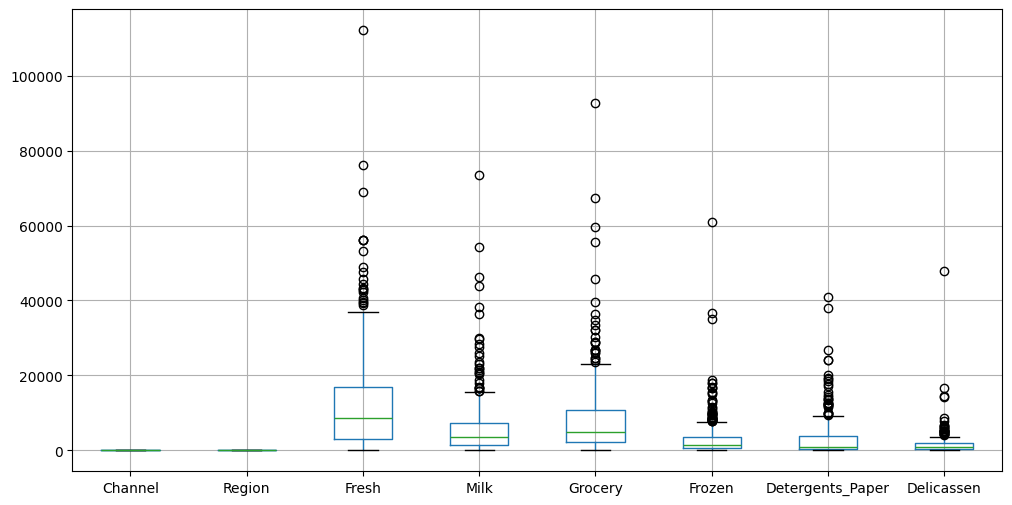

In [45]:
df.boxplot(figsize=(12,6))
plt.show()

#lots of outliers, some people who buy a huge amount while most of them spend the same amountrange

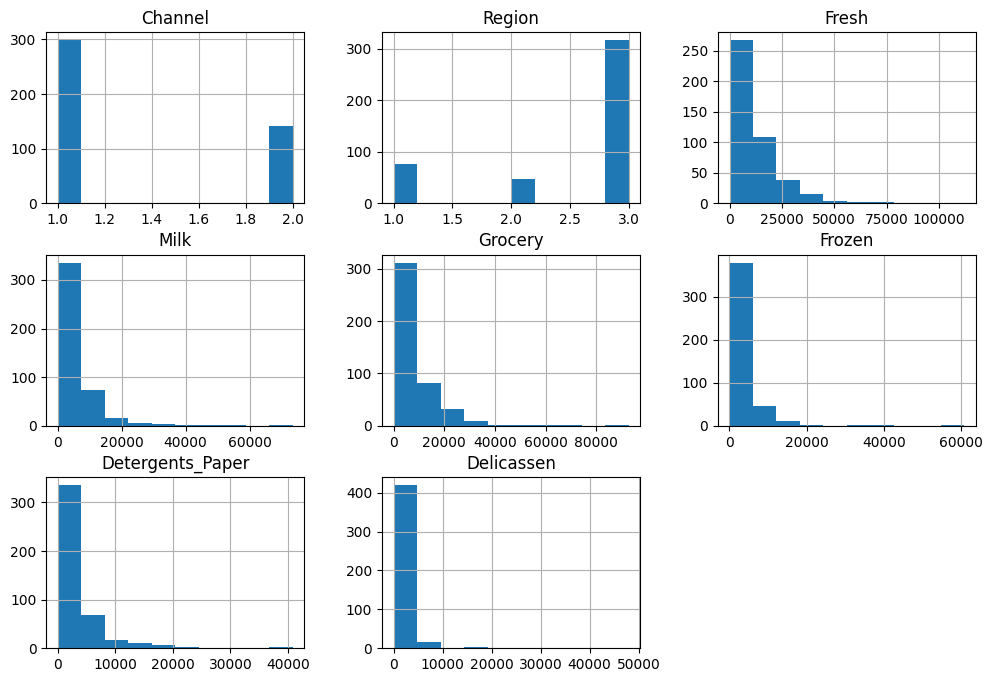

In [46]:
df.hist(figsize=(12,8))
plt.show()
#some customers buy a huge amoutn while most of them buy the same spendingrange which is much lower than the outliers

**Your observations here**

i put all my observations under the codeblocks or under the code in markup



In [49]:
for col in df.columns:
    print(col)

Fresh
Milk
Grocery
Frozen
Detergents_Paper
Delicassen
Channel_2
Region_2
Region_3


# Challenge 2 - Data Cleaning and Transformation

If your conclusion from the previous challenge is the data need cleaning/transformation, do it in the cells below. However, if your conclusion is the data need not be cleaned or transformed, feel free to skip this challenge. But if you do choose the latter, please provide rationale.

In [56]:

dummy_cols = [col for col in df.columns if col.startswith("Channel_") or col.startswith("Region_")]


df[dummy_cols] = df[dummy_cols].astype(int) 



**Your comment here**

-  #i want to change the categorical columns to one hot encode ones so my model doesnt think 1 is more important than 2 etc.
-  i drop the detergents_paper column cause it has big correlation with groceries columns

In [57]:
df

,Fresh,Milk,Grocery,Frozen,Delicassen,Channel_2,Region_2,Region_3
0,12669,9656,7561,214,1338,1,0,1
1,7057,9810,9568,1762,1776,1,0,1
2,6353,8808,7684,2405,7844,1,0,1
3,13265,1196,4221,6404,1788,0,0,1
4,22615,5410,7198,3915,5185,1,0,1
...,...,...,...,...,...,...,...,...
435,29703,12051,16027,13135,2204,0,0,1
436,39228,1431,764,4510,2346,0,0,1
437,14531,15488,30243,437,1867,1,0,1
438,10290,1981,2232,1038,2125,0,0,1


# Challenge 3 - Data Preprocessing

One problem with the dataset is the value ranges are remarkably different across various categories (e.g. `Fresh` and `Grocery` compared to `Detergents_Paper` and `Delicassen`). If you made this observation in the first challenge, you've done a great job! This means you not only completed the bonus questions in the previous Supervised Learning lab but also researched deep into [*feature scaling*](https://en.wikipedia.org/wiki/Feature_scaling). Keep on the good work!

Diverse value ranges in different features could cause issues in our clustering. The way to reduce the problem is through feature scaling. We'll use this technique again with this dataset.

#### We will use the `StandardScaler` from `sklearn.preprocessing` and scale our data. Read more about `StandardScaler` [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler).

*After scaling your data, assign the transformed data to a new variable `customers_scale`.*

In [74]:
# Your import here:

from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)


customers_scale = pd.DataFrame(scaled_data, columns=df.columns)


customers_scale.head()


,Fresh,Milk,Grocery,Frozen,Delicassen,Channel_2,Region_2,Region_3
0,0.052933,0.523568,-0.041115,-0.589367,-0.066339,1.448652,-0.345822,0.626422
1,-0.391302,0.544458,0.170318,-0.270136,0.089151,1.448652,-0.345822,0.626422
2,-0.447029,0.408538,-0.028157,-0.137536,2.243293,1.448652,-0.345822,0.626422
3,0.100111,-0.624020,-0.392977,0.687144,0.093411,-0.690297,-0.345822,0.626422
4,0.840239,-0.052396,-0.079356,0.173859,1.299347,1.448652,-0.345822,0.626422


# Challenge 4 - Data Clustering with K-Means

Now let's cluster the data with K-Means first. Initiate the K-Means model, then fit your scaled data. In the data returned from the `.fit` method, there is an attribute called `labels_` which is the cluster number assigned to each data record. What you can do is to assign these labels back to `customers` in a new column called `customers['labels']`. Then you'll see the cluster results of the original data.

In [77]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
customers = customers_scale
kmeans.fit(customers)

kmeans.labels_


customers["labels"] = kmeans.labels_
customers

,Fresh,Milk,Grocery,Frozen,Delicassen,Channel_2,Region_2,Region_3,labels
0,0.052933,0.523568,-0.041115,-0.589367,-0.066339,1.448652,-0.345822,0.626422,0
1,-0.391302,0.544458,0.170318,-0.270136,0.089151,1.448652,-0.345822,0.626422,0
2,-0.447029,0.408538,-0.028157,-0.137536,2.243293,1.448652,-0.345822,0.626422,0
3,0.100111,-0.624020,-0.392977,0.687144,0.093411,-0.690297,-0.345822,0.626422,1
4,0.840239,-0.052396,-0.079356,0.173859,1.299347,1.448652,-0.345822,0.626422,0
...,...,...,...,...,...,...,...,...,...
435,1.401312,0.848446,0.850760,2.075222,0.241091,-0.690297,-0.345822,0.626422,1
436,2.155293,-0.592142,-0.757165,0.296561,0.291501,-0.690297,-0.345822,0.626422,1
437,0.200326,1.314671,2.348386,-0.543380,0.121456,1.448652,-0.345822,0.626422,0
438,-0.135384,-0.517536,-0.602514,-0.419441,0.213046,-0.690297,-0.345822,0.626422,1


### Looking to the elbow we can choose 2 like the correct number of clusters

In [79]:
kmeans_2 = KMeans(n_clusters=2).fit(customers)

labels = kmeans_2.predict(customers)

clusters = kmeans_2.labels_.tolist()

In [82]:
customers['Label'] = clusters

customers

,Fresh,Milk,Grocery,Frozen,Delicassen,Channel_2,Region_2,Region_3,labels,Label
0,0.052933,0.523568,-0.041115,-0.589367,-0.066339,1.448652,-0.345822,0.626422,0,0
1,-0.391302,0.544458,0.170318,-0.270136,0.089151,1.448652,-0.345822,0.626422,0,0
2,-0.447029,0.408538,-0.028157,-0.137536,2.243293,1.448652,-0.345822,0.626422,0,0
3,0.100111,-0.624020,-0.392977,0.687144,0.093411,-0.690297,-0.345822,0.626422,1,1
4,0.840239,-0.052396,-0.079356,0.173859,1.299347,1.448652,-0.345822,0.626422,0,0
...,...,...,...,...,...,...,...,...,...,...
435,1.401312,0.848446,0.850760,2.075222,0.241091,-0.690297,-0.345822,0.626422,1,1
436,2.155293,-0.592142,-0.757165,0.296561,0.291501,-0.690297,-0.345822,0.626422,1,1
437,0.200326,1.314671,2.348386,-0.543380,0.121456,1.448652,-0.345822,0.626422,0,0
438,-0.135384,-0.517536,-0.602514,-0.419441,0.213046,-0.690297,-0.345822,0.626422,1,1


Count the values in `labels`.

In [88]:
customers["labels"].value_counts().sort_index()

labels
0    138
1    294
2      8
Name: count, dtype: int64

# Challenge 5 - Data Clustering with DBSCAN

Now let's cluster the data using DBSCAN. Use `DBSCAN(eps=0.5)` to initiate the model, then fit your scaled data. In the data returned from the `.fit` method, assign the `labels_` back to `customers['labels_DBSCAN']`. Now your original data have two labels, one from K-Means and the other from DBSCAN.

In [136]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5)
dbscan.fit(scaled_data)

customers['labels_DBSCAN'] = dbscan.labels_
labels_DBSCAN = dbscan.labels_


Count the values in `labels_DBSCAN`.

In [137]:
dbscan.labels_

customers["labels_DBSCAN"] = dbscan.labels_
customers["labels_DBSCAN"].value_counts().sort_index()


labels_DBSCAN
-1    222
 0     31
 1      7
 2    138
 3      5
 4     23
 5      7
 6      7
Name: count, dtype: int64

In [138]:
customers

,Fresh,Milk,Grocery,Frozen,Delicassen,Channel_2,Region_2,Region_3,labels,Label,labels_DB,labels_DBSCAN
0,0.052933,0.523568,-0.041115,-0.589367,-0.066339,1.448652,-0.345822,0.626422,0,0,4,0
1,-0.391302,0.544458,0.170318,-0.270136,0.089151,1.448652,-0.345822,0.626422,0,0,4,0
2,-0.447029,0.408538,-0.028157,-0.137536,2.243293,1.448652,-0.345822,0.626422,0,0,-1,-1
3,0.100111,-0.624020,-0.392977,0.687144,0.093411,-0.690297,-0.345822,0.626422,1,1,-1,2
4,0.840239,-0.052396,-0.079356,0.173859,1.299347,1.448652,-0.345822,0.626422,0,0,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...
435,1.401312,0.848446,0.850760,2.075222,0.241091,-0.690297,-0.345822,0.626422,1,1,-1,-1
436,2.155293,-0.592142,-0.757165,0.296561,0.291501,-0.690297,-0.345822,0.626422,1,1,-1,-1
437,0.200326,1.314671,2.348386,-0.543380,0.121456,1.448652,-0.345822,0.626422,0,0,-1,-1
438,-0.135384,-0.517536,-0.602514,-0.419441,0.213046,-0.690297,-0.345822,0.626422,1,1,1,2


# Challenge 6 - Compare K-Means with DBSCAN

Now we want to visually compare how K-Means and DBSCAN have clustered our data. We will create scatter plots for several columns. For each of the following column pairs, plot a scatter plot using `labels` and another using `labels_DBSCAN`. Put them side by side to compare. Which clustering algorithm makes better sense?

Columns to visualize:

* `Detergents_Paper` as X and `Milk` as y
* `Grocery` as X and `Fresh` as y
* `Frozen` as X and `Delicassen` as y

Visualize `Detergents_Paper` as X and `Milk` as y by `labels` and `labels_DBSCAN` respectively

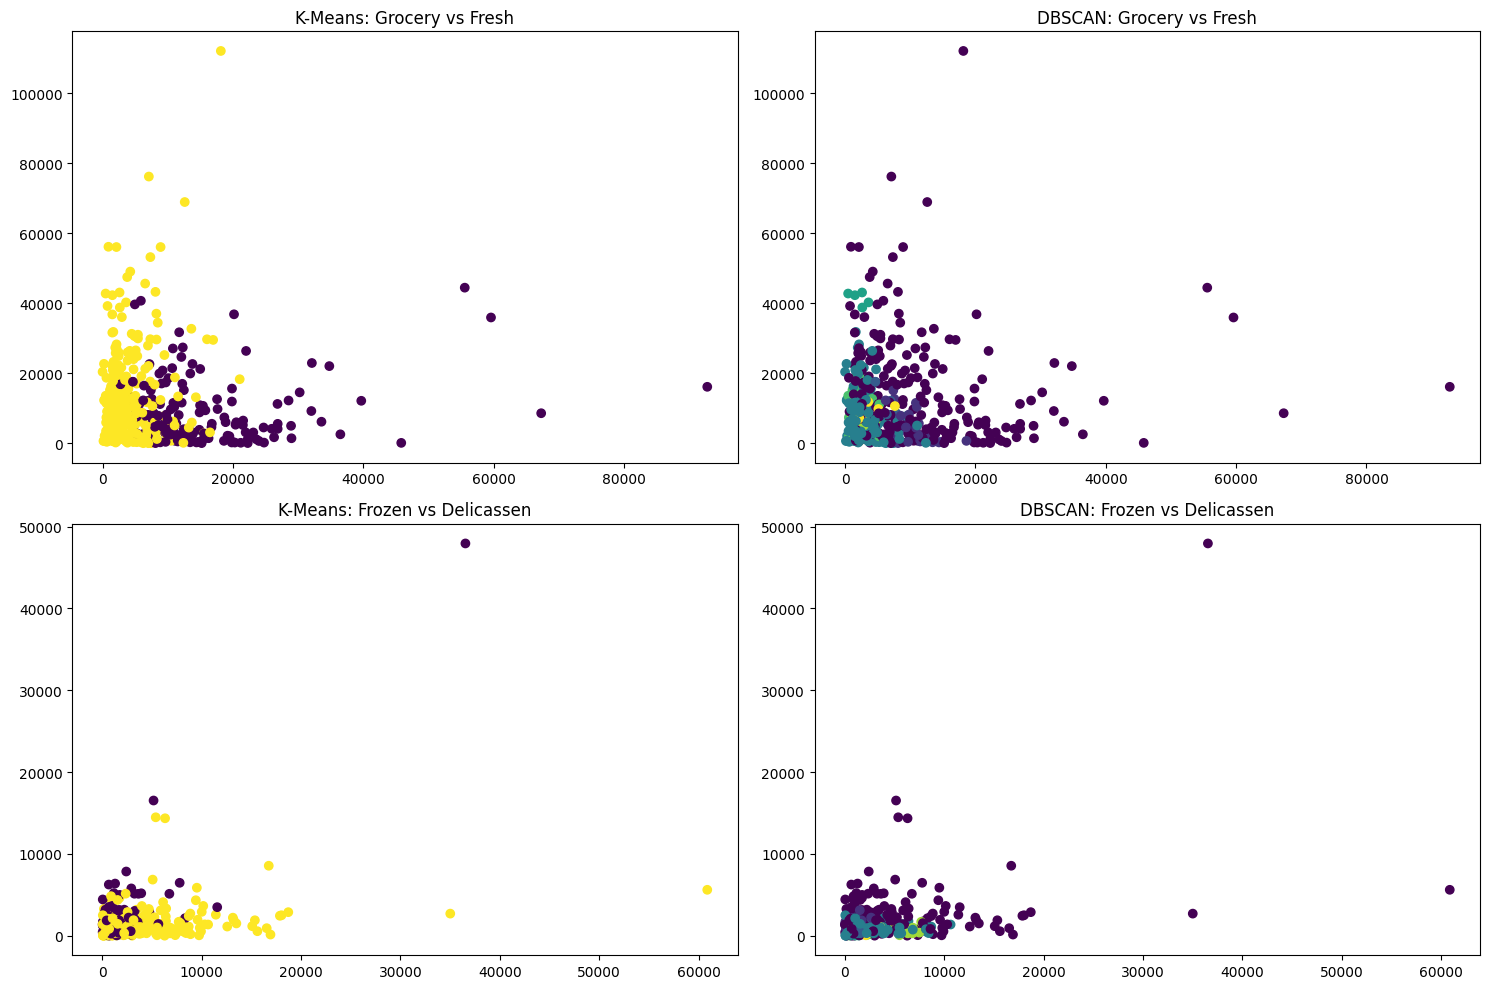

In [139]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Grocery vs Fresh
axes[0, 0].scatter(df["Grocery"], df["Fresh"], c=labels)
axes[0, 0].set_title("K-Means: Grocery vs Fresh")
axes[0, 1].scatter(df["Grocery"], df["Fresh"], c=labels_DBSCAN)
axes[0, 1].set_title("DBSCAN: Grocery vs Fresh")

# Frozen vs Delicassen
axes[1, 0].scatter(df["Frozen"], df["Delicassen"], c=labels)
axes[1, 0].set_title("K-Means: Frozen vs Delicassen")
axes[1, 1].scatter(df["Frozen"], df["Delicassen"], c=labels_DBSCAN)
axes[1, 1].set_title("DBSCAN: Frozen vs Delicassen")

plt.tight_layout()
plt.show()



Visualize `Grocery` as X and `Fresh` as y by `labels` and `labels_DBSCAN` respectively

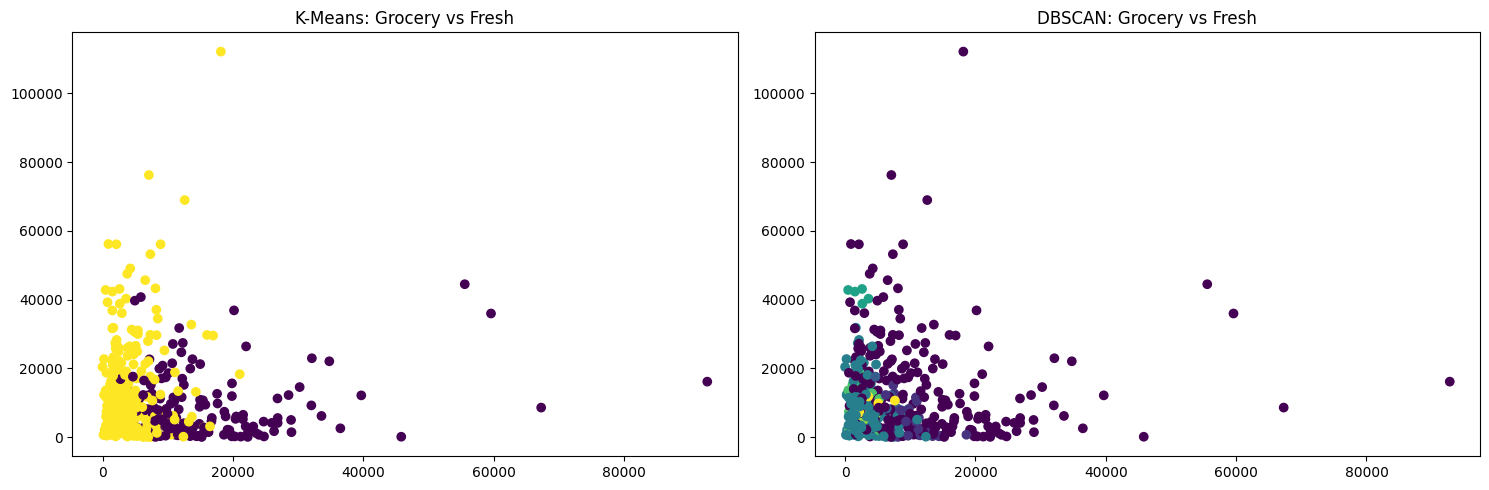

In [140]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(df["Grocery"], df["Fresh"], c=labels)
axes[0].set_title("K-Means: Grocery vs Fresh")

axes[1].scatter(df["Grocery"], df["Fresh"], c=labels_DBSCAN)
axes[1].set_title("DBSCAN: Grocery vs Fresh")

plt.tight_layout()
plt.show()

Visualize `Frozen` as X and `Delicassen` as y by `labels` and `labels_DBSCAN` respectively

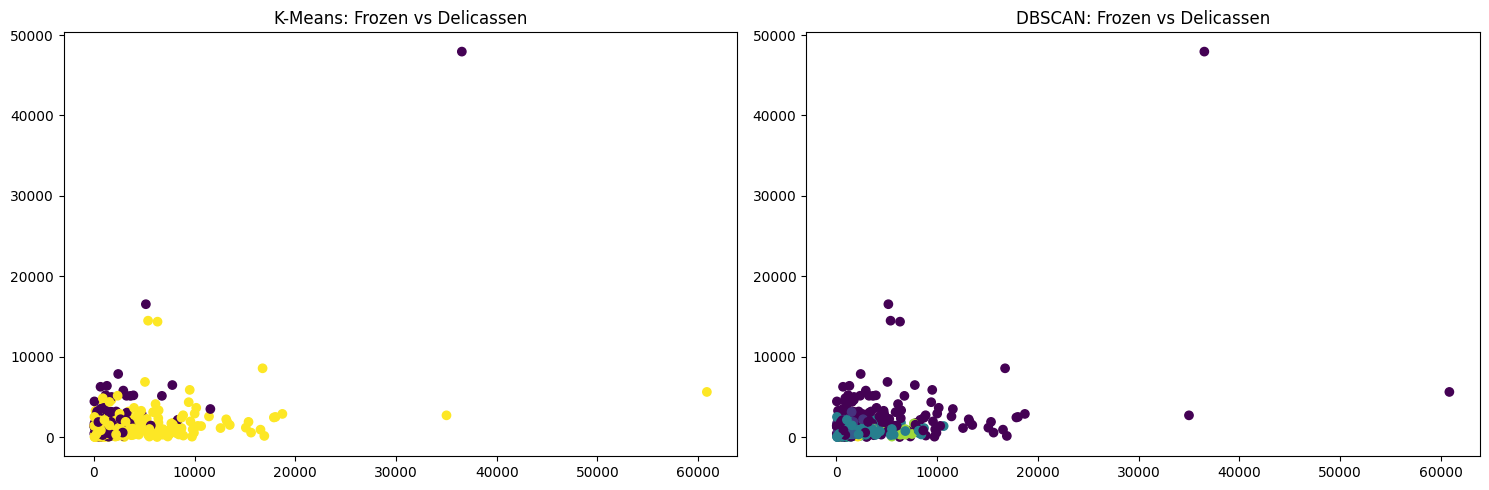

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(df["Frozen"], df["Delicassen"], c=labels)
axes[0].set_title("K-Means: Frozen vs Delicassen")

axes[1].scatter(df["Frozen"], df["Delicassen"], c=labels_DBSCAN)
axes[1].set_title("DBSCAN: Frozen vs Delicassen")

plt.tight_layout()
plt.show()

Let's use a groupby to see how the mean differs between the groups. Group `customers` by `labels` and `labels_DBSCAN` respectively and compute the means for all columns.

In [143]:
customers.groupby(labels).mean()
customers.groupby(labels_DBSCAN).mean()

,Fresh,Milk,Grocery,Frozen,Delicassen,Channel_2,Region_2,Region_3,labels,Label,labels_DB,labels_DBSCAN
-1,0.225430,0.397877,0.419460,0.228517,0.247550,0.311733,0.237508,-0.244671,0.585586,0.522523,-1.000000,-1.0
0,-0.587354,0.269773,0.262403,-0.467829,-0.044146,1.448652,-0.345822,0.626422,0.000000,0.000000,2.548387,0.0
1,0.041998,-0.350417,-0.193147,-0.454380,-0.416775,1.448652,-0.345822,0.626422,0.000000,0.000000,0.000000,1.0
2,-0.250519,-0.514376,-0.547781,-0.200273,-0.278321,-0.690297,-0.345822,0.626422,1.000000,1.000000,1.173913,2.0
3,2.330913,-0.593472,-0.609298,-0.370277,-0.262725,-0.690297,-0.345822,0.626422,1.000000,1.000000,3.000000,3.0
4,-0.198600,-0.555547,-0.617203,-0.326497,-0.311011,-0.690297,-0.345822,-1.596367,1.000000,1.000000,4.695652,4.0
5,-0.391144,-0.522923,-0.595064,0.712421,-0.304544,-0.690297,-0.345822,-1.596367,1.000000,1.000000,7.000000,5.0
6,-0.272667,-0.549917,-0.414453,-0.147965,-0.237601,-0.690297,2.891661,-1.596367,1.000000,1.000000,9.000000,6.0


Which algorithm appears to perform better?

kmeans

**Your observations here**
kmeans
- 

# Bonus Challenge 2 - Changing K-Means Number of Clusters

As we mentioned earlier, we don't need to worry about the number of clusters with DBSCAN because it automatically decides that based on the parameters we send to it. But with K-Means, we have to supply the `n_clusters` param (if you don't supply `n_clusters`, the algorithm will use `8` by default). You need to know that the optimal number of clusters differs case by case based on the dataset. K-Means can perform badly if the wrong number of clusters is used.

In advanced machine learning, data scientists try different numbers of clusters and evaluate the results with statistical measures (read [here](https://en.wikipedia.org/wiki/Cluster_analysis#External_evaluation)). We are not using statistical measures today but we'll use our eyes instead. In the cells below, experiment with different number of clusters and visualize with scatter plots. What number of clusters seems to work best for K-Means?

**Your comment here**

- 

# Bonus Challenge 3 - Changing DBSCAN `eps` and `min_samples`

Experiment changing the `eps` and `min_samples` params for DBSCAN. See how the results differ with scatter plot visualization.

In [ ]:
# Your code here

**Your comment here**

- 